# Часть 1а: LDA

Ноутбук для финального подбора числа тем LDA и вывода топ-слов лучшей модели по coherence.

## 0. Подготовка среды

In [1]:
#импорты
import re
import string
import os
import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from joblib import Parallel, delayed
from tqdm.auto import tqdm
tqdm.pandas()

from stop_words import get_stop_words
from pymorphy3 import MorphAnalyzer

from gensim import corpora, models
from gensim.models import CoherenceModel

print("Все библиотеки загружены.")


Все библиотеки загружены.


In [2]:
#настройки
DATA_DIR = "."
FILE_PART1 = os.path.join(DATA_DIR, "output_cursovaya_part1.xlsx")
FILE_PART2 = os.path.join(DATA_DIR, "output_cursovaya_part2.xlsx")

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LDA_OUTPUT_DIR = OUTPUT_DIR / "lda"
LDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

RUN_LDA = True
TUNE_SAMPLE = 15_000
PREPROCESS_N_JOBS = max(1, min(8, (os.cpu_count() or 2) - 1))

print(f"Данные: {FILE_PART1}, {FILE_PART2}")
print(f"Результаты: {LDA_OUTPUT_DIR}/")
print(f"Seed: {SEED}")
print(f"RUN_LDA: {RUN_LDA}")
print(f"PREPROCESS_N_JOBS: {PREPROCESS_N_JOBS}")


Данные: .\output_cursovaya_part1.xlsx, .\output_cursovaya_part2.xlsx
Результаты: results\lda/
Seed: 42
RUN_LDA: True
PREPROCESS_N_JOBS: 8


## 1. Загрузка и предобработка данных

In [3]:
#загрузка данных
def get_usecols(xlsx_path):
    cols = pd.read_excel(xlsx_path, nrows=0, engine="openpyxl").columns.tolist()
    needed = ["post_id", "message_id", "date", "channel_ref", "channel", "text"]
    return [c for c in needed if c in cols]

usecols_part1 = get_usecols(FILE_PART1)
usecols_part2 = get_usecols(FILE_PART2)
usecols = sorted(list(set(usecols_part1) | set(usecols_part2)))

df1 = pd.read_excel(FILE_PART1, usecols=usecols, engine="openpyxl")
df2 = pd.read_excel(FILE_PART2, usecols=usecols, engine="openpyxl")

df = pd.concat([df1, df2], ignore_index=True).drop_duplicates().reset_index(drop=True)
print(df.shape)
display(df.head())

(1093965, 4)


,channel,message_id,date,text
0,@RKadyrov_95,4361,2024-01-15 07:00:13+00:00,Сегодня рано утром сотрудники МВД России по Ше...
1,@RKadyrov_95,4362,2024-01-15 09:16:26+00:00,"Беспомощная ситуация жителей сектора Газа, кот..."
2,@RKadyrov_95,4363,2024-01-15 14:34:46+00:00,И снова группа «Аида» спецназа «АХМАТ» в работ...
3,@RKadyrov_95,4364,2024-01-16 08:25:50+00:00,Друзья! Сегодня многочисленные поздравления с ...
4,@RKadyrov_95,4365,2024-01-16 19:23:46+00:00,"Друзья! Проект, подготовленный и реализованный..."


In [4]:
#базовая очистка
df = df.loc[df["text"].notna()].reset_index(drop=True)
df["text"] = df["text"].astype(str)
df = df.loc[df["text"].str.strip().ne("")].reset_index(drop=True)

if "channel_ref" not in df.columns:
    df["channel_ref"] = df.get("channel", "unknown_channel").astype(str)
df["channel_ref"] = df["channel_ref"].astype("category")

df["text_raw"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
df = df.reset_index(drop=True)
df["doc_id"] = np.arange(len(df), dtype=np.int64)

print(df[["doc_id", "channel_ref", "date", "text_raw"]].head())

   doc_id   channel_ref                       date  \
0       0  @RKadyrov_95  2024-01-15 07:00:13+00:00   
1       1  @RKadyrov_95  2024-01-15 09:16:26+00:00   
2       2  @RKadyrov_95  2024-01-15 14:34:46+00:00   
3       3  @RKadyrov_95  2024-01-16 08:25:50+00:00   
4       4  @RKadyrov_95  2024-01-16 19:23:46+00:00   

                                            text_raw  
0  Сегодня рано утром сотрудники МВД России по Ше...  
1  Беспомощная ситуация жителей сектора Газа, кот...  
2  И снова группа «Аида» спецназа «АХМАТ» в работ...  
3  Друзья! Сегодня многочисленные поздравления с ...  
4  Друзья! Проект, подготовленный и реализованный...  


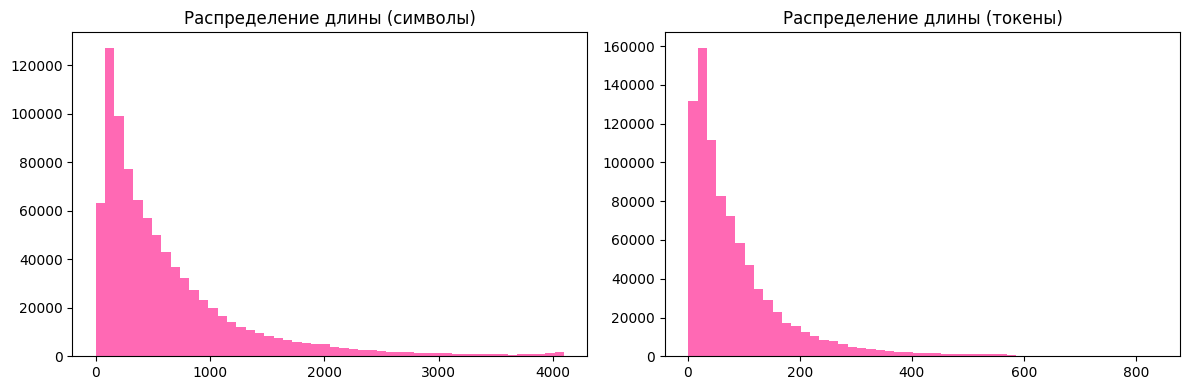

In [5]:
#распределение длины текстов
df["len_chars"] = df["text_raw"].str.len()
df["len_tokens_raw"] = df["text_raw"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["len_chars"], bins=50, color="hotpink")
axes[0].set_title("Распределение длины (символы)")
axes[1].hist(df["len_tokens_raw"], bins=50, color="hotpink")
axes[1].set_title("Распределение длины (токены)")
plt.tight_layout()
plt.show()

## 2. Лемматизация и очистка текста

In [6]:
#стоп-слова и очистка
stop_ru = set(get_stop_words("russian"))
stop_en = set(get_stop_words("english"))

custom_stop = {
    "канал", "канале", "каналу", "каналом", "каналы",
    "подписаться", "подписка", "подписывайтесь", "подпишись", "подпишитесь",
    "telegram", "телеграм", "телеграмм",
    "смотреть", "смотрите", "посмотреть",
    "читать", "читайте",
    "новость", "новости",
    "видео", "эфир", "эфире", "стрим", "трансляция", "live",
    "репост", "переслать", "поделиться",
    "rutube", "рутуб", "пул", "max",
}

topic_noise_stop = {
    "заявить", "сообщить", "сказать", "который", "очень", "вообще", "никто", "никакой",
    "сегодня", "вчера", "завтра", "просто", "это", "весь", "ещё", "также",
    "будьте", "находитесь", "улице", "помещениях", "окон",

    "детей", "дети", "ребенка", "ребёнка", "человека", "человек", "людей", "люди",
    "возможности", "возможность", "условиях", "условия", "условии",
    "например", "рассказал", "рассказала", "стало", "данные", "нового", "новый",
    "работы", "работа", "средств", "средства", "движения", "движение",
    "рост", "частных", "центра", "округе", "районах", "районах населенных",
    "некоторых", "основное", "временно", "объединений", "проживающих", "гражданства",
    "ситуацию", "ситуация", "версия", "ответить", "встреча", "рассказать",

    "instagram", "youtube", "whatsapp", "google", "meta", "vpn", "wifi",
    "cnn", "reuters", "bloomberg", "fox", "telegraph", "wsj", "nyt", "abc", "newsweek",
    "politico", "journal", "times", "post", "social", "digital", "business", "national",
    "axios", "arabiya", "unherd", "pais", "bild", "oracle", "apple", "tesla",
    "svt", "lrt", "dpa", "corp", "online", "week", "report", "data", "info",

    "tmervvoenkor", "rua", "engblueskywhatsapp", "xix", "shot", "baza", "upd", "zergulio",
    "boosty", "sponsr", "metametrica", "izru", "mash", "mashru", "ura", "rtvi", "вчк-огпу",

    "бпла", "всу", "сво", "рф", "сша", "ес", "оон", "мвд", "фбр", "мтс",
    "млн", "млрд", "трлн", "руб", "рублей", "долларов", "доллара", "евро",
    "года", "году", "лет", "год", "месяц", "день", "дней",

    "области", "область", "районе", "район", "городе", "города", "страны", "страна",
    "территории", "территорией", "территория", "окрестности", "округе",
    "взрыв", "взрывы", "поражены", "восстановлено", "боевых", "боевые",
    "серия", "анализ", "построили", "должность", "производства", "освобождение",
    "подразделений", "подразделения", "компаний", "российского", "специальной",
    "специальной военной", "военной", "народной", "населенных", "населенных пунктов",

    "герань", "герани", "гербера", "герберы", "умпк", "fpv", "отрк", "himars",
    "atacms", "storm", "shadow", "patriot", "nasams", "thaad", "tomahawk",
    "баба", "яга", "баба-яга", "патч", "патч-антенна",

    "проверяйте", "убедитесь", "ориентировочно", "номер", "класс",
    "девочка", "животных", "наушники", "авокадо", "роботы", "деревьев", "доски",
    "мафия", "коррупция", "мусора", "красная", "тихий", "горя", "плохие",
}

stopwords_all = stop_ru | stop_en | custom_stop
vectorizer_stopwords = stopwords_all | topic_noise_stop

punct = set(string.punctuation + '\u00ab\u00bb\u2014\u2026\u201c\u201d\u0060\u2018\u2019\u2013')
morph = MorphAnalyzer(lang="ru")

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+", " ", text)
    text = re.sub(r"[^a-zа-яё\d\s-]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords_all and t not in punct and len(t) > 2 and not t.isdigit()]
    lemmas = [morph.parse(t)[0].normal_form for t in tokens]
    return " ".join(lemmas)

def preprocess_text_bert(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+", " ", text)
    text = re.sub(r"\bподпиш(?:ись|итесь|ись)\b", " ", text)
    text = re.sub(r"\btelegram\b|\bтелеграм(?:м)?\b|\brutube\b|\bрутуб\b", " ", text)
    text = re.sub(r"\b(?:instagram|youtube|whatsapp|google|meta|vpn|wifi|cnn|reuters|bloomberg|fox|telegraph|wsj|nyt|abc|newsweek|politico)\b", " ", text)
    text = re.sub(r"\b(?:tmervvoenkor|rua|engblueskywhatsapp|xix|shot|baza|upd|zergulio|boosty|sponsr|metametrica|izru|mash)\b", " ", text)
    text = re.sub(r"\b(?:млн|млрд|трлн|руб|рублей|долларов|доллара|евро|бпла|всу|сво|рф|сша|ес|оон)\b", " ", text)
    text = re.sub(r"\b[a-z]{1,4}\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Функции предобработки готовы.")

Функции предобработки готовы.


In [7]:
#предобработка корпуса
def _apply_on_chunk(chunk, func):
    return chunk.apply(func)

def parallel_apply(series, func, n_jobs=1):
    n_jobs = max(1, int(n_jobs))
    if n_jobs == 1:
        return series.progress_apply(func)

    index_chunks = np.array_split(np.arange(len(series)), n_jobs)
    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_apply_on_chunk)(series.iloc[idx], func) for idx in index_chunks if len(idx) > 0
    )
    return pd.concat(results).sort_index()

df["text_clean"] = parallel_apply(df["text_raw"], preprocess_text, n_jobs=PREPROCESS_N_JOBS)
df["len_tokens_clean"] = df["text_clean"].str.split().str.len()

before = len(df)
df = df[df["len_tokens_clean"] > 3].reset_index(drop=True)

print(f"Документов после фильтрации: {len(df):,} (убрано {before - len(df):,} коротких)")

Документов после фильтрации: 847,743 (убрано 18,386 коротких)


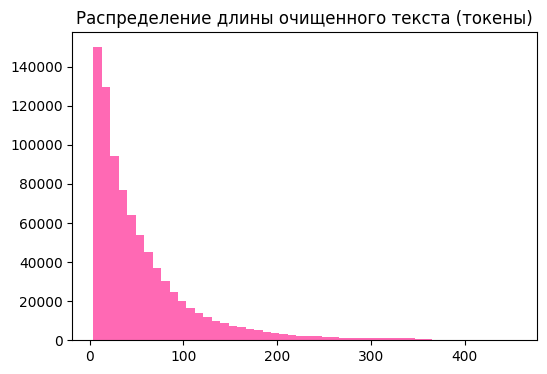

In [8]:
#распределение длины очищенного текста
lens = df["text_clean"].str.split().str.len()
plt.figure(figsize=(6, 4))
plt.hist(lens, bins=50, color="hotpink")
plt.title("Распределение длины очищенного текста (токены)")
plt.show()

## 3. LDA

In [9]:
#tuning-sample для lda
tune_n = min(TUNE_SAMPLE, len(df))
df_tune = df.sample(tune_n, random_state=SEED).reset_index(drop=True)
print(f"Tuning-sample: {tune_n:,} документов")

tokenized_tune = df_tune["text_clean"].astype(str).apply(lambda x: x.split()).tolist()
dictionary_lda = corpora.Dictionary(tokenized_tune)
dictionary_lda.filter_extremes(no_below=50, no_above=0.5)
corpus_tune = [dictionary_lda.doc2bow(doc) for doc in tokenized_tune]

lda_tune_pack = {
    "df_tune": df_tune,
    "tokenized_tune": tokenized_tune,
    "dictionary": dictionary_lda,
    "corpus_tune": corpus_tune,
}

print(f"Словарь LDA: {len(dictionary_lda):,} токенов")


Tuning-sample: 15,000 документов
Словарь LDA: 2,698 токенов


In [10]:
#подбор lda
import time

topic_nums = [5, 10, 15, 20, 25, 30, 40]
coherences, perplexities = [], []

best_coh = -1e9
best_k = None
lda_best = None

coh_sample_n = 750
idx = np.random.RandomState(SEED).choice(len(tokenized_tune), size=min(coh_sample_n, len(tokenized_tune)), replace=False)
texts_coh = [tokenized_tune[i] for i in idx]

for k in topic_nums:
    print(f"\nLDA k={k}...", flush=True)

    t0 = time.time()
    lda = models.LdaModel(
        corpus=corpus_tune,
        id2word=dictionary_lda,
        num_topics=k,
        random_state=SEED,
        chunksize=4096,
        passes=4,
        iterations=120,
        alpha="auto",
        eta="auto",
        minimum_probability=0.0,
        eval_every=None,
    )
    print(f"  fit: {time.time() - t0:.1f} sec", flush=True)

    t1 = time.time()
    cm = CoherenceModel(model=lda, texts=texts_coh, dictionary=dictionary_lda, coherence="c_v", processes=1)
    coh = float(cm.get_coherence())
    print(f"  coherence: {time.time() - t1:.1f} sec", flush=True)

    t2 = time.time()
    perp = float(np.exp2(-lda.log_perplexity(corpus_tune)))
    print(f"  perplexity: {time.time() - t2:.1f} sec", flush=True)

    coherences.append(coh)
    perplexities.append(perp)
    print(f"  coherence={coh:.4f}, perplexity={perp:.1f}", flush=True)

    if coh > best_coh:
        best_coh, best_k, lda_best = coh, k, lda
    else:
        del lda

    del cm
    gc.collect()

print(f"\nЛучшее число тем по coherence: {best_k} (coherence={best_coh:.4f})")



LDA k=5...
  fit: 14.4 sec
  coherence: 0.2 sec
  perplexity: 3.6 sec
  coherence=0.4239, perplexity=146.7

LDA k=10...
  fit: 14.5 sec
  coherence: 0.3 sec
  perplexity: 3.8 sec
  coherence=0.4100, perplexity=144.2

LDA k=15...
  fit: 14.5 sec
  coherence: 0.4 sec
  perplexity: 3.8 sec
  coherence=0.4175, perplexity=144.8

LDA k=20...
  fit: 14.3 sec
  coherence: 0.5 sec
  perplexity: 3.8 sec
  coherence=0.3978, perplexity=145.1

LDA k=25...
  fit: 14.3 sec
  coherence: 0.7 sec
  perplexity: 3.8 sec
  coherence=nan, perplexity=146.0

LDA k=30...
  fit: 14.2 sec
  coherence: 0.8 sec
  perplexity: 3.9 sec
  coherence=0.4141, perplexity=149.0

LDA k=40...
  fit: 14.3 sec
  coherence: 1.1 sec
  perplexity: 3.9 sec
  coherence=nan, perplexity=153.6

Лучшее число тем по coherence: 5 (coherence=0.4239)


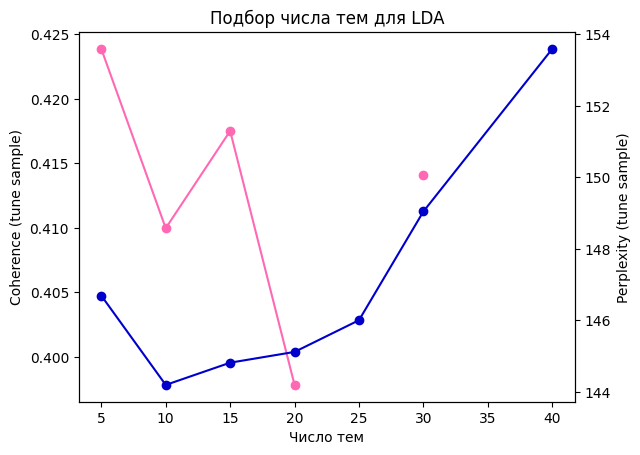

In [11]:
#график lda
if topic_nums:
    fig, ax1 = plt.subplots()
    ax1.plot(topic_nums, coherences, marker="o", color="hotpink")
    ax1.set_xlabel("Число тем")
    ax1.set_ylabel("Coherence (tune sample)")

    ax2 = ax1.twinx()
    ax2.plot(topic_nums, perplexities, marker="o", color="mediumblue")
    ax2.set_ylabel("Perplexity (tune sample)")

    plt.title("Подбор числа тем для LDA")
    plt.show()

In [12]:
#топ-слова лучшей lda
def lda_topic_words_table(model, topn=15):
    rows = []
    for topic_id in range(model.num_topics):
        words = model.show_topic(topic_id, topn=topn)
        rows.append({
            "topic_id": int(topic_id),
            "top_words": ", ".join([w for w, _ in words]),
        })
    return pd.DataFrame(rows)

lda_results_df = pd.DataFrame({
    "n_topics": topic_nums,
    "coherence_c_v": coherences,
    "perplexity": perplexities,
}).sort_values("coherence_c_v", ascending=False).reset_index(drop=True)

lda_top_words_df = lda_topic_words_table(lda_best, topn=15)

display(lda_results_df)
print(f"Лучшее число тем по coherence: {best_k} (coherence={best_coh:.4f})")
display(lda_top_words_df)

lda_results_df.to_excel(LDA_OUTPUT_DIR / "lda_tuning_results.xlsx", index=False)
lda_results_df.to_csv(LDA_OUTPUT_DIR / "lda_tuning_results.csv", index=False, encoding="utf-8-sig")

lda_top_words_df.to_excel(LDA_OUTPUT_DIR / "lda_best_top_words.xlsx", index=False)
lda_top_words_df.to_csv(LDA_OUTPUT_DIR / "lda_best_top_words.csv", index=False, encoding="utf-8-sig")

lda_best.save(str(LDA_OUTPUT_DIR / "lda_best_model.gensim"))

print(LDA_OUTPUT_DIR / "lda_tuning_results.xlsx")
print(LDA_OUTPUT_DIR / "lda_best_top_words.xlsx")
print(LDA_OUTPUT_DIR / "lda_best_model.gensim")


,n_topics,coherence_c_v,perplexity
0,5,0.423872,146.693566
1,15,0.417517,144.819177
2,30,0.414070,149.047922
3,10,0.409979,144.197265
4,20,0.397837,145.120459
5,25,NaN,146.007032
6,40,NaN,153.594468


Лучшее число тем по coherence: 5 (coherence=0.4239)


,topic_id,top_words
0,0,"русский, россия, наш, человек, страна, первый,..."
1,1,"всу, область, район, противник, удар, украинск..."
2,2,"область, whatsapp, платформa, eng, bluesky, ре..."
3,3,"россия, новый, страна, российский, компания, п..."
4,4,"украина, сша, россия, трамп, президент, путин,..."


results\lda\lda_tuning_results.xlsx
results\lda\lda_best_top_words.xlsx
results\lda\lda_best_model.gensim
